# Submission Comparison Dashboard

This notebook provides an automated way to compare your latest submission against your best benchmark. Use this tool iteratively during model tuning to track performance shifts and verify consistency.

### 0. Generate Latest Submission (Optional)
Run this cell to update `submissions/submission.csv` using the current model and training pipeline. This ensures you are comparing the most up-to-date version.

In [227]:
!cd .. && python -m src.training.pipeline

--- Starting Baseline Pipeline ---
Calculating Data-driven Sample Weights...
Training Normalized Revenue Model...
Starting Optimized Signal Discovery...
Discovery complete: Found 73 pure event signals.
Starting Category Profile Discovery...
Category discovery complete: Profiles for 12 months created.
Training COGS Ratio Model...
Starting Dynamic Inertia Weight Discovery...
Learned Inertia Weights: Rev=0.256, Order=0.713, AOV=-0.456
Inertia Confidence (R2): 1.000 -> Trust Weight: 0.95
Data-driven Damping: 0.925 (based on YoY volatility 0.150)
Dynamic Inertia Applied (Calibrated M: 1.192x)
Generating stationary recursive forecast (Optimized)...
--- Done! Saved Baseline to e:\VSCODE_WORKSPACE\NewDatathon\submissions\submission.csv ---


### 1. Configuration
Define the paths to the submissions you want to compare.

In [228]:
CURRENT_SUB_PATH = '../submissions/submission.csv'
BEST_SUB_PATH = '../data/best_submit/best_750k.csv'

### 2. Setup & Data Loading

In [229]:
import pandas as pd
import numpy as np
from IPython.display import display
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set plot styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

def load_and_align(curr_path, best_path):
    if not os.path.exists(curr_path):
        raise FileNotFoundError(f"Current submission not found: {curr_path}")
    if not os.path.exists(best_path):
        raise FileNotFoundError(f"Best submission not found: {best_path}")
        
    df_curr = pd.read_csv(curr_path, parse_dates=['Date'])
    df_best = pd.read_csv(best_path, parse_dates=['Date'])
    
    df = pd.merge(df_curr, df_best, on='Date', suffixes=('_curr', '_best'))
    return df

df = load_and_align(CURRENT_SUB_PATH, BEST_SUB_PATH)
df.head()

,Date,Revenue_curr,COGS_curr,Revenue_best,COGS_best
0,2023-01-01,2.917899e+06,2.770929e+06,3.817429e+06,3.263002e+06
1,2023-01-02,1.900623e+06,1.630457e+06,1.844059e+06,1.586606e+06
2,2023-01-03,1.677776e+06,1.350817e+06,1.722395e+06,1.480858e+06
3,2023-01-04,1.384999e+06,1.113274e+06,1.525194e+06,1.313823e+06
4,2023-01-05,1.652847e+06,1.336714e+06,1.519344e+06,1.306116e+06


### 3. Interactive Comparison Dashboard
Compare the raw values of Revenue and COGS over time.

In [230]:
def plot_comparison(df, target):
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=df['Date'], y=df[f'{target}_best'],
        name=f'{target} (Best)',
        line=dict(color='rgba(0, 0, 0, 0.4)', width=2, dash='dot')
    ))
    
    fig.add_trace(go.Scatter(
        x=df['Date'], y=df[f'{target}_curr'],
        name=f'{target} (Current)',
        line=dict(color='#636EFA', width=3)
    ))
    
    fig.update_layout(
        title=f'{target} Comparison: Current vs Best',
        xaxis_title='Date',
        yaxis_title=target,
        hovermode='x unified',
        template='plotly_white',
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    
    fig.show()

plot_comparison(df, 'Revenue')
plot_comparison(df, 'COGS')

### 4. Deviation & Bias Analysis
Identify where the current model deviates from the benchmark. A positive delta means the current forecast is higher than the best benchmark.

In [231]:
for target in ['Revenue', 'COGS']:
    df[f'{target}_delta'] = df[f'{target}_curr'] - df[f'{target}_best']
    df[f'{target}_pct_diff'] = (df[f'{target}_delta'] / df[f'{target}_best']) * 100

def plot_delta(df, target):
    fig = go.Figure()
    
    # Area for delta
    fig.add_trace(go.Scatter(
        x=df['Date'], y=df[f'{target}_delta'],
        fill='tozeroy',
        name='Delta (Curr - Best)',
        line=dict(color='#EF553B')
    ))
    
    # Rolling average of delta
    fig.add_trace(go.Scatter(
        x=df['Date'], y=df[f'{target}_delta'].rolling(7).mean(),
        name='7-Day Rolling Mean of Delta',
        line=dict(color='#00CC96', width=2)
    ))
    
    fig.update_layout(
        title=f'{target} Deviation over Time',
        xaxis_title='Date',
        yaxis_title='Absolute Difference',
        hovermode='x unified',
        template='plotly_white'
    )
    fig.show()

plot_delta(df, 'Revenue')
plot_delta(df, 'COGS')

### 5. Distribution of Differences
Visualizing the scale and consistency of the changes.

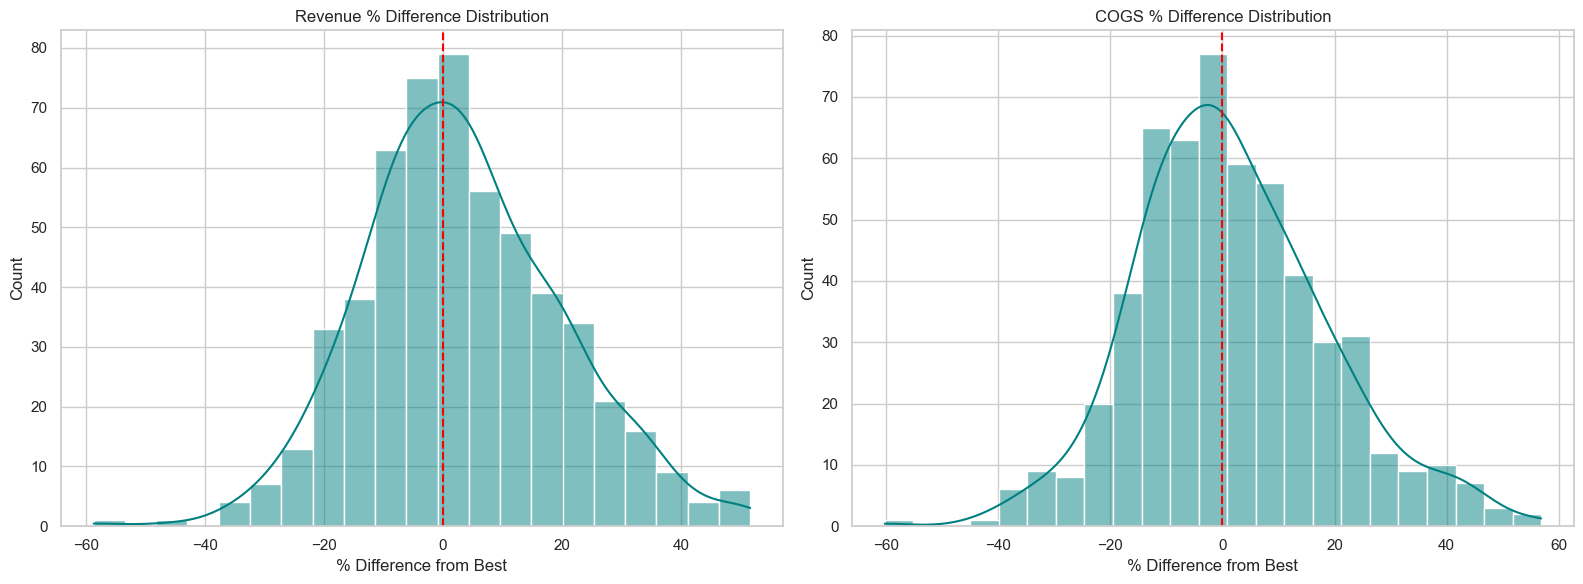

In [232]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, target in enumerate(['Revenue', 'COGS']):
    sns.histplot(df[f'{target}_pct_diff'], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'{target} % Difference Distribution')
    axes[i].set_xlabel('% Difference from Best')
    axes[i].axvline(0, color='red', linestyle='--')
    
plt.tight_layout()
plt.show()

### 6. Summary Statistics Dashboard

In [233]:
stats = []
for target in ['Revenue', 'COGS']:
    curr_col = f'{target}_curr'
    best_col = f'{target}_best'
    
    mae = (df[curr_col] - df[best_col]).abs().mean()
    corr = df[curr_col].corr(df[best_col])
    mean_ratio = df[curr_col].mean() / df[best_col].mean()
    
    stats.append({
        'Target': target,
        'Pearson Corr': corr, # Keep as float for color styling
        'MAE vs Best': float(mae), # Keep as float to sum later
        'Scale Ratio (Curr/Best)': f"{mean_ratio:.4f}",
        'Abs % Diff Mean': f"{df[f'{target}_pct_diff'].abs().mean():.2f}%"
    })

# Total MAE calculation before string formatting
total_mae = sum([stat['MAE vs Best'] for stat in stats])

# Formatting the individual MAE values to strings for display
for stat in stats:
    stat['MAE vs Best'] = f"{stat['MAE vs Best']:,.2f}"

# Append summary row with np.nan for numeric columns
stats.append({
    'Target': 'TOTAL (Rev + COGS)',
    'Pearson Corr': np.nan, 
    'MAE vs Best': f"{total_mae:,.2f}",
    'Scale Ratio (Curr/Best)': '-',
    'Abs % Diff Mean': '-'
})

stats_df = pd.DataFrame(stats)

# Apply styling to float values, ignoring NaNs which automatically get skipped by Pandas Styler background_gradient
display(stats_df.style.set_caption("Summary Comparison Metrics").background_gradient(cmap='Blues', subset=['Pearson Corr']))

,Target,Pearson Corr,MAE vs Best,Scale Ratio (Curr/Best),Abs % Diff Mean
0,Revenue,0.950112,"564,062.42",1.0419,13.30%
1,COGS,0.942658,"477,378.28",1.0219,13.34%
2,TOTAL (Rev + COGS),nan,"1,041,440.70",-,-


### 7. Top 20 Revenue Discrepancy Days
Identifying the specific dates where the current model deviates most from the benchmark.

In [234]:
df['Revenue_abs_diff'] = (df['Revenue_curr'] - df['Revenue_best']).abs()
top_20 = df.sort_values('Revenue_abs_diff', ascending=False).head(20)

print("=== TOP 20 REVENUE DISCREPANCY DAYS ===")
display(top_20[['Date', 'Revenue_curr', 'Revenue_best', 'Revenue_abs_diff']])

=== TOP 20 REVENUE DISCREPANCY DAYS ===


,Date,Revenue_curr,Revenue_best,Revenue_abs_diff
484,2024-04-29,1.444099e+07,1.095711e+07,3.483886e+06
118,2023-04-29,1.170017e+07,8.883209e+06,2.816962e+06
485,2024-04-30,1.207181e+07,9.281967e+06,2.789841e+06
458,2024-04-03,1.108060e+07,8.293825e+06,2.786772e+06
153,2023-06-03,1.018478e+07,7.446063e+06,2.738721e+06
479,2024-04-24,8.679155e+06,6.054784e+06,2.624371e+06
457,2024-04-02,1.105987e+07,8.494492e+06,2.565376e+06
119,2023-04-30,9.868129e+06,7.381537e+06,2.486592e+06
515,2024-05-30,1.447635e+07,1.216110e+07,2.315250e+06
470,2024-04-15,7.142043e+06,5.042958e+06,2.099086e+06
